In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [4]:
bilancia_timestamps, thicknesses, rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, 'data/points.txt'))

bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]

print(max(bilancia_trel))

1690.033730506897


In [5]:
elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')

In [6]:
keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)

keithley_currents = np.array(keithley_currents)
keithley_timestamps = np.array(keithley_timestamps)
keithley_trel = keithley_timestamps - keithley_timestamps[0]

print(max(keithley_trel))

4187.232023


In [7]:
auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])
plus2_inds = auto_range_indices - 1
plus1_inds = auto_range_indices - 2


elettrometro_series = {
    "auto": (keithley_trel[auto_range_indices], keithley_currents[auto_range_indices]),
    "+2": (keithley_trel[plus2_inds], keithley_currents[plus2_inds]),
    "+1": (keithley_trel[plus1_inds], keithley_currents[plus1_inds])
}


In [8]:
# interpolazione correnti sui timestamp della bilancia

elettrometro_series_interpolated = {}

start_time = 1800


for key, (t_rel, currents) in elettrometro_series.items():

    # select only data points where t >= start_time

    mask_elettrometro = t_rel >= start_time
    mask_bilancia = bilancia_trel >= start_time

    t_rel = t_rel[mask_elettrometro]
    currents = currents[mask_elettrometro]

    bilancia_trel_masked = bilancia_trel[mask_bilancia]

    print(len(t_rel), len(currents), len(bilancia_trel_masked))
    
    interpolated_currents = np.interp(bilancia_trel_masked, t_rel, currents)
    elettrometro_series_interpolated[key] = (bilancia_trel_masked, interpolated_currents)
    

3071 3071 0
3071 3071 0
3070 3070 0


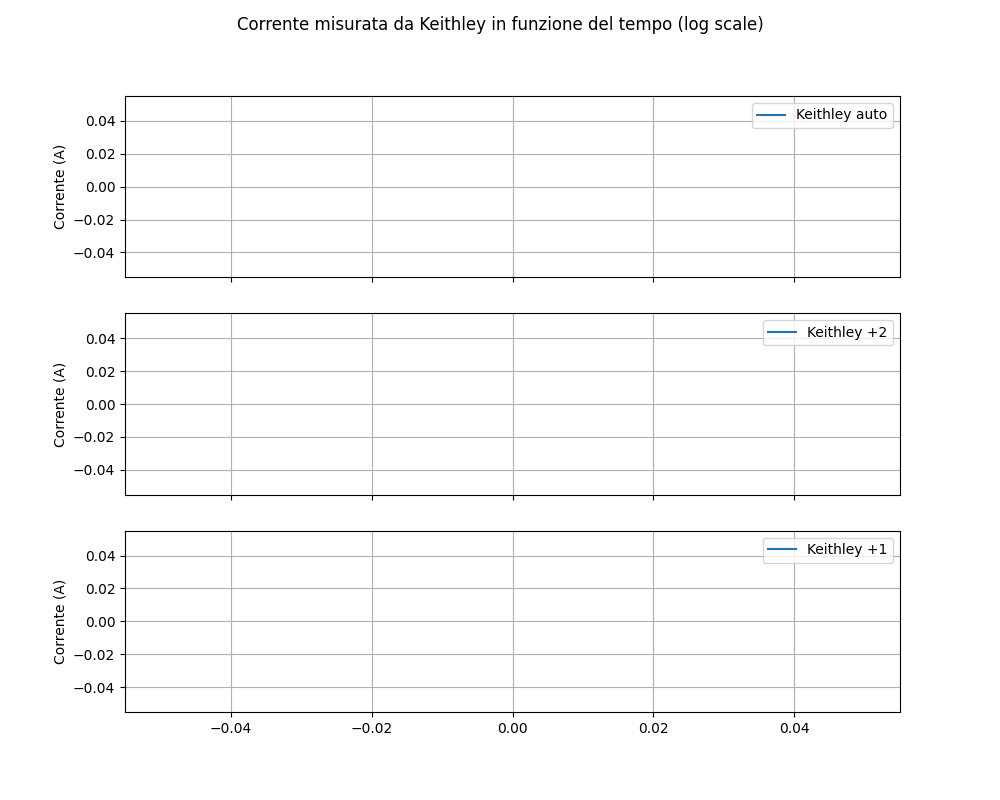

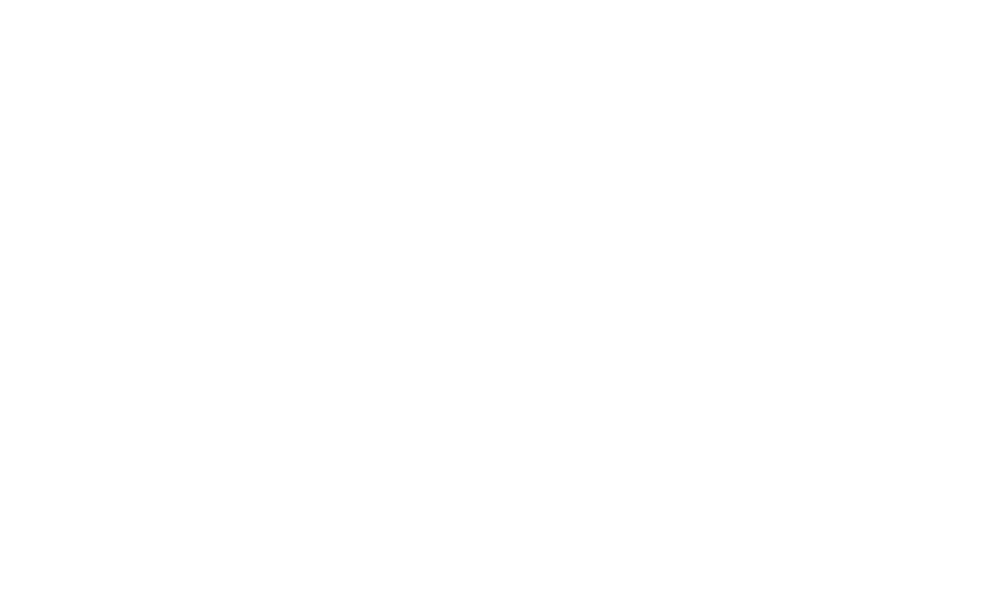

In [9]:
plt.figure(figsize=(10, 6))

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

fig.suptitle('Corrente misurata da Keithley in funzione del tempo (log scale)')


for ax, (key, val) in zip(axes, elettrometro_series_interpolated.items()):
    t, curr = val

    
    ax.plot(t, curr, label=f'Keithley {key}', marker='', linestyle='-', markersize=4)
    #ax.set_yscale('log')
    ax.set_ylabel('Corrente (A)')
    ax.legend()
    ax.grid(True)
    #ax.set_ylim(np.min(curr), np.max(curr))

plt.show()